First notebook (`01_Generate_Synthetic_LightCurve.ipynb`) generates the **ground-truth light curve exactly once**, using the parameters described in Chapter 3:

* Baseline flux: $\mu = 1.0$
* Amplitude: $A = 0.1$
* Period: $P = 1.0$ day
* Phase: $\phi = 0$
* Gaussian noise: $\sigma = 0.02$
* Cadence: $\Delta t = 29.4$ minutes $= 0.0204$ days
* Duration: $27$ days
* Random seed: $0$


- ## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["font.size"] = 12

- ## Define Parameters

In [2]:
# ===========================
# Synthetic Signal Parameters
# ===========================

MU = 1.0                 # Baseline flux
AMPLITUDE = 0.10         # Signal amplitude
PERIOD = 1.0             # days
PHASE = 0.0              # radians
SIGMA = 0.02             # Gaussian noise

CADENCE = 0.0204         # days (29.4 minutes)

DURATION = 27            # days

SEED = 0

- ## Random Seed

In [3]:
np.random.seed(SEED)

- ## Generate Time Array

In [4]:
time = np.arange(0, DURATION, CADENCE)

N = len(time)

print(f"Number of observations = {N}")

Number of observations = 1324


- ## Generate Ideal Signal

In [5]:
ideal_flux = (
    MU
    + AMPLITUDE
    * np.sin(
        2 * np.pi * time / PERIOD + PHASE
    )
)

- ## Add Gaussian Noise

In [6]:
noise = np.random.normal(
    loc=0,
    scale=SIGMA,
    size=N
)

observed_flux = ideal_flux + noise

- ## Create DataFrame

In [7]:
lightcurve = pd.DataFrame({
    "time": time,
    "ideal_flux": ideal_flux,
    "noise": noise,
    "observed_flux": observed_flux
})

lightcurve.head()

,time,ideal_flux,noise,observed_flux
0,0.0000,1.000000,0.035281,1.035281
1,0.0204,1.012783,0.008003,1.020786
2,0.0408,1.025356,0.019575,1.044930
3,0.0612,1.037512,0.044818,1.082330
4,0.0816,1.049054,0.037351,1.086405


- ## Plot the Signal

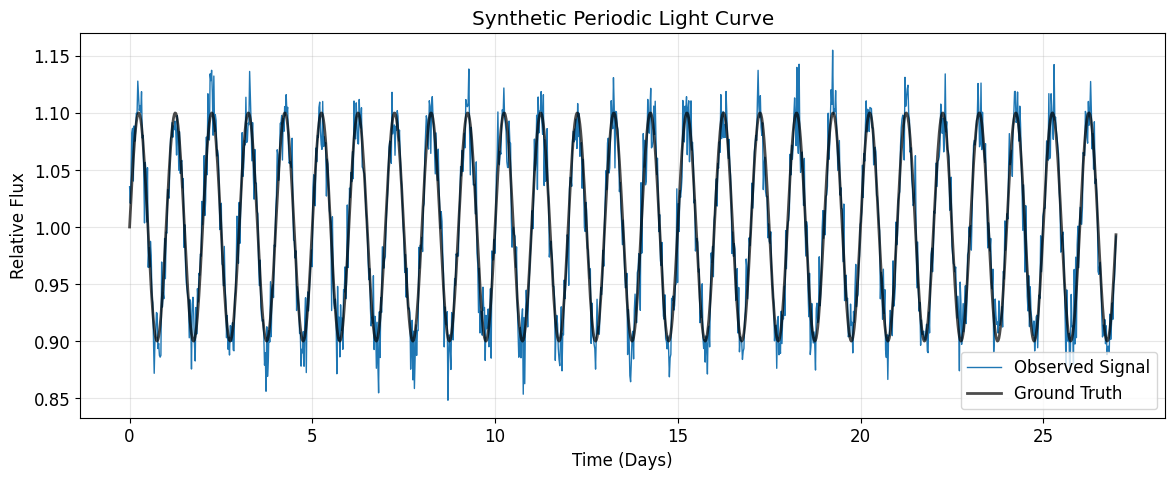

In [8]:
plt.figure(figsize=(14,5))

plt.plot(
    time,
    observed_flux,
    color="tab:blue",
    lw=1,
    label="Observed Signal"
)

plt.plot(
    time,
    ideal_flux,
    color="black",
    lw=2,
    alpha=0.7,
    label="Ground Truth"
)

plt.xlabel("Time (Days)")
plt.ylabel("Relative Flux")
plt.title("Synthetic Periodic Light Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

- ## Save Dataset

In [9]:
lightcurve.to_csv(
    "synthetic_lightcurve.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.


- ## Summary Statistics

In [10]:
print("========== Signal Summary ==========")

print(f"Number of Cadences : {N}")
print(f"Duration           : {DURATION} days")
print(f"Cadence            : {CADENCE:.4f} days")
print(f"Period             : {PERIOD} day")
print(f"Amplitude          : {AMPLITUDE}")
print(f"Noise Sigma        : {SIGMA}")
print(f"SNR                : {AMPLITUDE/SIGMA:.1f}")

========== Signal Summary ==========
Number of Cadences : 1324
Duration           : 27 days
Cadence            : 0.0204 days
Period             : 1.0 day
Amplitude          : 0.1
Noise Sigma        : 0.02
SNR                : 5.0
